Reading Parquet file...


Successfully loaded 93264 rows.


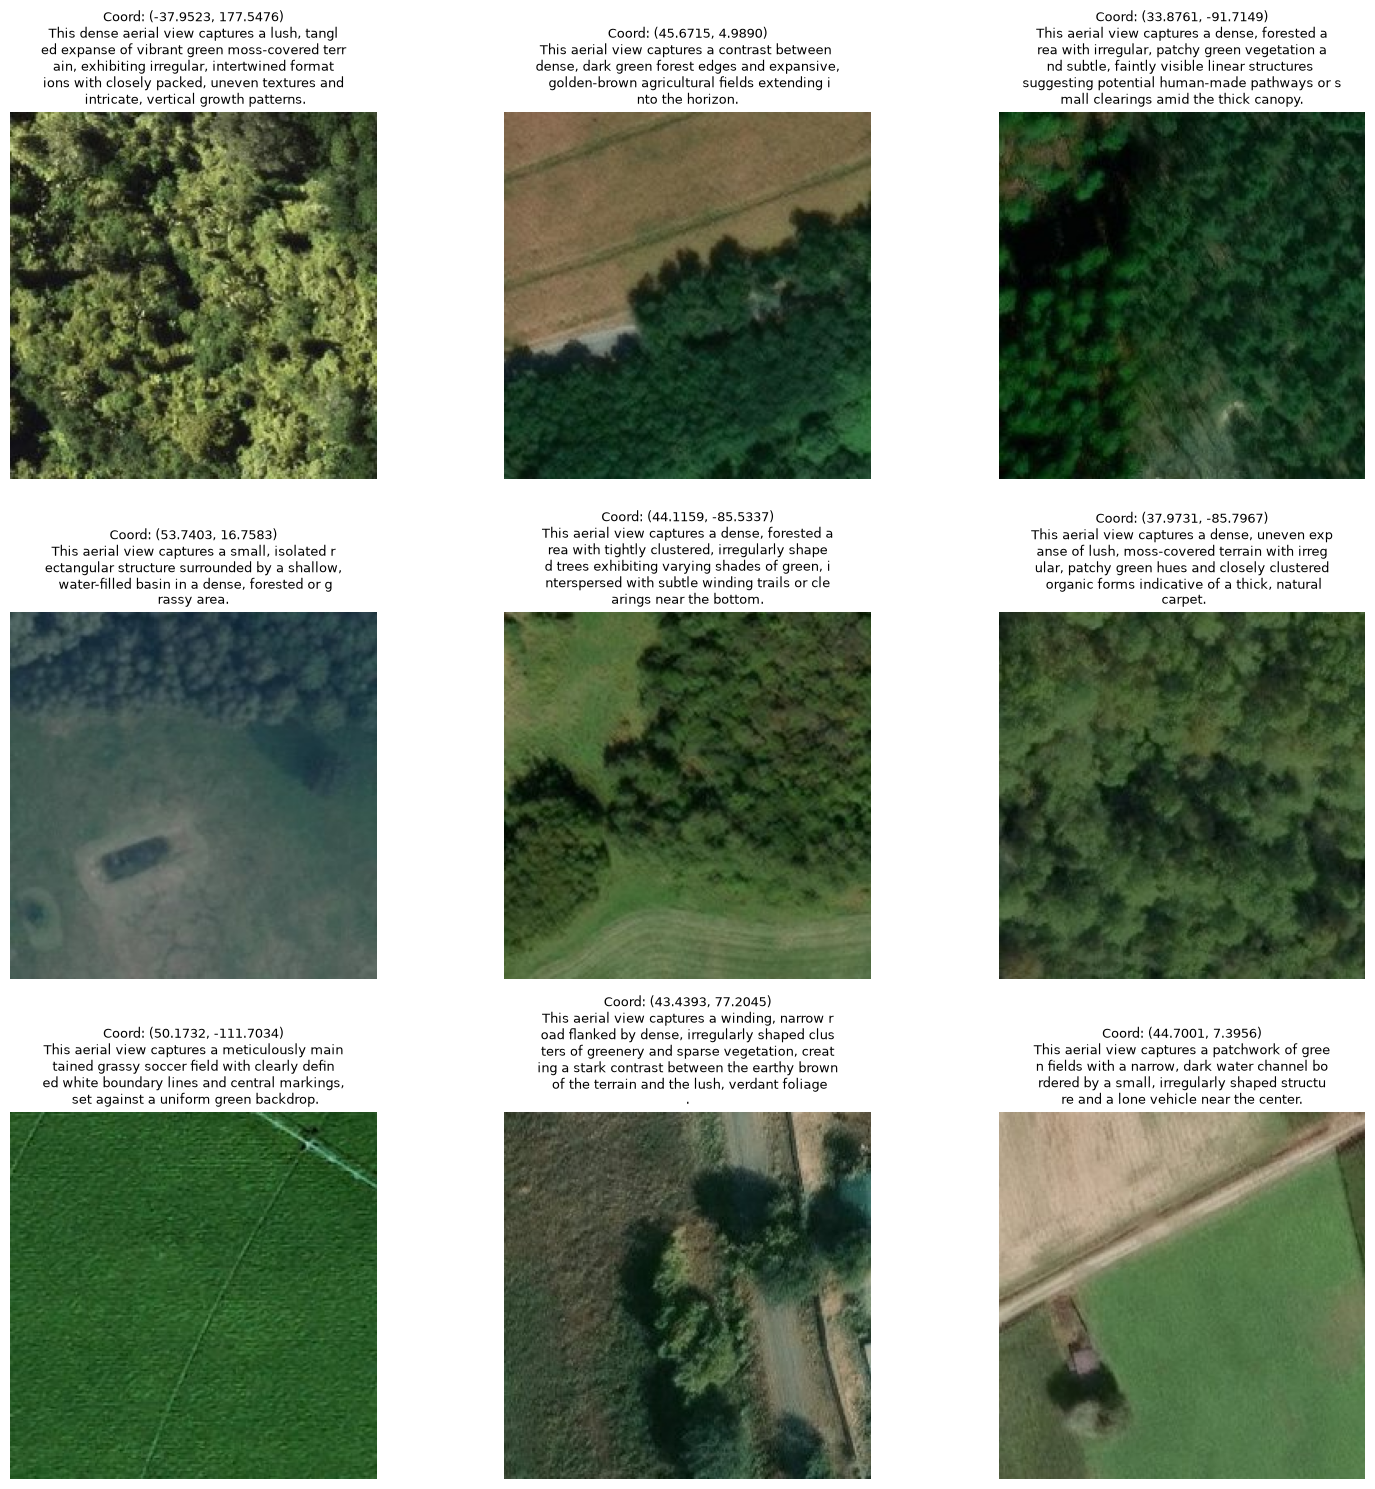

In [19]:
import os
import random
from io import BytesIO
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# --- Configuration ---
PARQUET_PATH = r"/data/susanket/queryearth/vlm_captions.parquet"

def main():
    if not os.path.exists(PARQUET_PATH):
        print(f"Error: Parquet file not found at {PARQUET_PATH}")
        return

    print("Reading Parquet file...")
    # Read only the necessary columns into a pandas DataFrame to save memory
    df = pd.read_parquet(PARQUET_PATH, columns=['caption', 'image_bytes', 'lat', 'lon'])
    
    total_rows = len(df)
    print(f"Successfully loaded {total_rows} rows.")
    
    if total_rows < 9:
        print("Warning: The dataset has fewer than 9 images. Plotting what is available.")
        indices = list(range(total_rows))
    else:
        # Randomly select 9 distinct indices
        indices = random.sample(range(total_rows), 9)

    # Set up a 3x3 plotting grid
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.flatten()  # Flatten the 2D array to a 1D list for easier looping

    for i, idx in enumerate(indices):
        if i >= len(axes):
            break
            
        row = df.iloc[idx]
        caption = row['caption']
        img_bytes = row['image_bytes']
        lat, lon = row['lat'], row['lon']

        ax = axes[i]
        
        try:
            # Decode the compressed JPEG bytes back into a viewable image object
            img = Image.open(BytesIO(img_bytes))
            ax.imshow(img)
            
            # Format title text: wrap long captions so they don't bleed into other subplots
            wrapped_caption = "\n".join([caption[j:j+45] for j in range(0, len(caption), 45)])
            ax.set_title(f"Coord: ({lat:.4f}, {lon:.4f})\n{wrapped_caption}", fontsize=9, wrap=True)
            
        except Exception as e:
            ax.text(0.5, 0.5, f"Error loading image:\n{str(e)}", ha='center', va='center')
            ax.set_title(f"Index: {idx} (Failed)")
            
        ax.axis('off')  # Hide spatial axis gridlines for visual clarity

    # Hide any remaining unused subplots if dataset had fewer than 9 elements
    for j in range(len(indices), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

In [1]:
import pandas as pd

df = pd.read_parquet(rf"/data/susanket/gdfmv2/zip/std_captions_2.parquet")

In [2]:
df

,AREA_DESC,caption
0,00001,"N’Dillingham, a remote and sparsely populated ..."
1,00002,"Yukon Flats, a remote and predominantly rural ..."
2,00003,The area within the Alaska Peninsula National ...
3,00004,"The area within the W Kenai Peninsula Borough,..."
4,00005,"In N Lake and Peninsula Borough, Alaska, the d..."
...,...,...
32152,99925,"Klawock, a small community in Alaska, presents..."
32153,99926,"Metlakatla, located in Alaska, is a community ..."
32154,99927,"Point Baker, a remote and sparsely populated a..."
32155,99929,"Wrangell, Alaska, as depicted by the provided ..."


In [4]:
text = df.caption.iloc[0]

In [5]:
print(len(text.split()))

458


---

In [17]:
import pandas as pd
import geopandas as gpd

df = pd.read_csv(rf"E:\Data\query-earth\GeoNames\US.csv")

C:\Users\sus14836\AppData\Local\Temp\ipykernel_24156\3934962328.py:4: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(rf"E:\Data\query-earth\GeoNames\US.csv")


In [18]:
df

,Unnamed: 0,geonameid,name,asciiname,alternatenames,latitude,longitude,country_code,cc2,admin1_code,admin2_code,admin3_code,admin4_code,population,elevation,dem,timezone,modification_date,amenity_name,type
0,0,2130830,Middle Reef,Middle Reef,NaN,51.98414,176.01982,US,NaN,AK,NaN,NaN,NaN,0,NaN,-9999,NaN,2022-05-25,reef,a surface-navigation hazard composed of consol...
1,1,2130833,McArthur Reef,McArthur Reef,NaN,52.06667,177.86667,US,NaN,AK,16.0,NaN,NaN,0,NaN,-9999,Asia/Kamchatka,2016-07-05,reef,a surface-navigation hazard composed of consol...
2,2,2130890,Buldir Reef,Buldir Reef,NaN,52.15229,176.35675,US,NaN,AK,NaN,NaN,NaN,0,NaN,-9999,NaN,2022-05-25,reef,a surface-navigation hazard composed of consol...
3,3,3577483,The Narrows,The Narrows,The Narrows,18.37502,-64.72517,US,VG,00,NaN,NaN,NaN,0,NaN,-9999,America/St_Thomas,2018-11-06,channel,"the deepest part of a stream, bay, lagoon, or ..."
4,4,3715657,Cape Lookout Shoals,Cape Lookout Shoals,Lookout Shoals,34.51206,-76.49326,US,NaN,NC,31.0,91396.0,NaN,0,NaN,-9999,America/New_York,2022-05-24,shoal(s),a surface-navigation hazard composed of uncons...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2241381,2241381,13645991,Thompson Library,Thompson Library,NaN,33.79417,-79.00993,US,NaN,SC,51.0,NaN,NaN,0,NaN,12,America/New_York,2026-06-19,library,A place in which information resources such as...
2241382,2241382,13645994,Bryan Information Commons,Bryan Information Commons,NaN,33.79462,-79.01081,US,NaN,SC,51.0,NaN,NaN,0,NaN,12,America/New_York,2026-06-19,library,A place in which information resources such as...
2241383,2241383,13665084,Lake Mdw,Lake Mdw,NaN,38.65726,-90.60092,US,NaN,MO,189.0,13605.0,NaN,0,NaN,159,America/Chicago,2026-06-29,house(s),a building used as a human habitation
2241384,2241384,13665308,Freeport (US),Freeport (US),NaN,28.93751,-95.33499,US,NaN,TX,39.0,NaN,NaN,0,NaN,1,America/Chicago,2026-07-10,port,a place provided with terminal and transfer fa...


In [19]:
df.admin1_code.value_counts()

admin1_code
CA    127962
TX    115102
NY     79449
MT     75807
TN     75200
PA     67147
OH     67126
IL     64670
GA     63085
VA     62582
MI     62157
FL     61219
OR     60964
AL     59775
NC     58452
MO     54999
NM     54964
CO     50957
MN     49420
AZ     49254
KY     47477
WI     44411
WA     43255
LA     42619
AR     42148
IA     40476
MS     40445
SC     38158
WV     35943
AK     35801
MD     33342
OK     33288
UT     33238
MA     31807
ID     31640
ME     31142
IN     30866
KS     30073
NE     29308
NV     28991
WY     28646
NJ     22608
SD     19364
CT     18066
NH     13994
ND     13152
HI     11684
VT     11317
RI      6430
DE      5659
DC      5437
00        20
Name: count, dtype: int64

In [20]:
df[df['admin1_code']=="CA"]

,Unnamed: 0,geonameid,name,asciiname,alternatenames,latitude,longitude,country_code,cc2,admin1_code,admin2_code,admin3_code,admin4_code,population,elevation,dem,timezone,modification_date,amenity_name,type
9,9,3981608,Tijuana River,Tijuana River,"Rio Tiajuana,Rio Tijuana,Río Tijuana,Tia Juana...",32.55668,-117.12865,US,NaN,CA,73.0,NaN,NaN,0,NaN,4,America/Los_Angeles,2020-03-02,stream,a body of running water moving to a lower leve...
10,10,4020151,Southern California Borderland,Southern California Borderland,NaN,32.50000,-118.50000,US,NaN,CA,NaN,NaN,NaN,0,NaN,-9999,America/Cambridge_Bay,2016-02-08,borderland,"a region adjacent to a continent, normally occ..."
11,11,4020231,Osborn Bank,Osborn Bank,NaN,33.36548,-119.04877,US,NaN,CA,NaN,NaN,NaN,0,NaN,-9999,America/Los_Angeles,2023-11-08,knoll,an elevation rising generally more than 500 me...
12,12,4020248,Monterey Canyon,Monterey Canyon,"Kan'on Monterej,Kan'on Monterey,Kan’on Montere...",36.66667,-122.08333,US,NaN,CA,NaN,NaN,NaN,0,NaN,-9999,America/Cambridge_Bay,2014-02-20,canyon,"a relatively narrow, deep depression with stee..."
1225128,1225128,5284484,Bethune Park,Bethune Park,NaN,33.98335,-118.25313,US,NaN,CA,37.0,NaN,NaN,0,49.0,52,America/Los_Angeles,2006-01-15,park,"an area, often of forested land, maintained as..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2241335,2241335,13608580,Holy Archangels Armenian Apostolic Church,Holy Archangels Armenian Apostolic Church,"Holy Archangels Armenian Apostolic Church,Srbo...",34.23951,-118.26646,US,NaN,CA,37.0,NaN,NaN,0,NaN,537,America/Los_Angeles,2026-04-11,church,a building for public Christian worship
2241358,2241358,13645794,Pelona Vista Park,Pelona Vista Park,NaN,34.56896,-118.13838,US,NaN,CA,37.0,11788304.0,NaN,0,NaN,843,America/Los_Angeles,2026-06-16,park,"an area, often of forested land, maintained as..."
2241359,2241359,13645795,Highland High School,Highland High School,NaN,34.59215,-118.17481,US,NaN,CA,37.0,11788304.0,NaN,0,NaN,834,America/Los_Angeles,2026-06-16,school,building(s) where instruction in one or more b...
2241360,2241360,13645796,David G. Millen Middleschool,David G. Millen Middleschool,NaN,34.59527,-118.17056,US,NaN,CA,37.0,11788304.0,NaN,0,NaN,834,America/Los_Angeles,2026-06-16,school,building(s) where instruction in one or more b...


In [22]:
sdf = df[df['admin1_code']=="CA"]
gdf = gpd.GeoDataFrame(
    sdf,
    geometry=gpd.points_from_xy(sdf.longitude, sdf.latitude),
    crs="EPSG:4326",
)

In [30]:
gdf.to_file(rf"E:\Data\query-earth\GeoNames\ca.shp")

In [26]:
len(df['amenity_name'].unique())

429

In [27]:
gdf['amenity'] = gdf['amenity_name']

In [29]:
gdf = gdf[['name', 'amenity', 'geometry']]

In [31]:
gdf2 = gpd.read_parquet(rf"D:\Code\query-earth\dlpk\embeddings\poi.parquet")

In [32]:
gdf2

,amenity,name,geometry
0,bank,Chase,POINT (-122.02073 36.97937)
1,toilets,None,POINT (-121.41902 40.68548)
2,drinking_water,None,POINT (-122.24535 37.865)
3,parking,Big Painted Cave Trail Parking,POINT (-121.51228 41.72942)
4,parking,Schonchin Butte Parking,POINT (-121.52534 41.74077)
...,...,...,...
209797,community_centre,Club Lincoln Crossing,POINT (-121.30524 38.87292)
209798,restaurant,Nick's Laguna Beach,POINT (-117.78248 33.5413)
209799,restaurant,Thai Bros,POINT (-117.78259 33.54174)
209800,bench,None,POINT (-117.78279 33.54128)


In [36]:
df = pd.concat([gdf, gdf2], ignore_index=True)

In [44]:
df["amenity"] = df["amenity"].str.split(";")
df = df.explode("amenity").reset_index(drop=True)

In [48]:
df

,name,amenity,geometry
0,Tijuana River,stream,POINT (-117.12865 32.55668)
1,Southern California Borderland,borderland,POINT (-118.5 32.5)
2,Osborn Bank,knoll,POINT (-119.04877 33.36548)
3,Monterey Canyon,canyon,POINT (-122.08333 36.66667)
4,Bethune Park,park,POINT (-118.25313 33.98335)
...,...,...,...
337803,Club Lincoln Crossing,community_centre,POINT (-121.30524 38.87292)
337804,Nick's Laguna Beach,restaurant,POINT (-117.78248 33.5413)
337805,Thai Bros,restaurant,POINT (-117.78259 33.54174)
337806,None,bench,POINT (-117.78279 33.54128)


In [49]:
df.to_parquet(rf"D:\Code\query-earth\dlpk\embeddings\poi2.parquet")

In [45]:
l = df.amenity.unique()

In [46]:
len(l)

720

In [47]:
l

array(['stream', 'borderland', 'knoll', 'canyon', 'park', 'mountain',
       'spring(s)', 'ridge(s)', 'mine(s)', 'school', 'dam', 'canal',
       'gap', 'swamp', 'building(s)', 'cape', 'populated place', nan,
       'beach', 'lake', 'plain(s)', 'camp(s)', 'depression(s)',
       'wharf(-ves)', 'overfalls', 'church', 'airport', 'post office',
       'library', 'pass', 'museum', 'cemetery', 'abandoned camp',
       'reservoir(s)', 'trail', 'section of populated place', 'bar',
       'valley', 'administrative division', 'road junction', 'marina',
       'historical populated place', 'abandoned airfield', 'heliport',
       'reef', 'cove(s)', 'abandoned populated place', 'bay', 'mall',
       'housing development', 'area', 'island', 'forest(s)',
       'golf course', 'hospital', 'military installation', 'resort',
       'house(s)', 'mountains', 'farm', 'well', 'reserve', 'bridge',
       'arch', 'channel', 'industrial area', 'sewage treatment plant',
       'slope(s)', 'second-order admini

In [50]:
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
from sentence_transformers import SentenceTransformer

# 1. Load model and clean input list (filter out NaN / None values)
model = SentenceTransformer('all-MiniLM-L6-v2')

# Drop None/NaN values from unique amenities
unique_amenities = [str(x) for x in df['amenity'].dropna().unique()]

# 2. Generate normalized embeddings (returns float32 numpy array)
embeddings = model.encode(unique_amenities, normalize_embeddings=True)

# 3. Create PyArrow Table
# We store embeddings as fixed-size lists or float lists for maximum query compatibility
amenities_array = pa.array(unique_amenities, type=pa.string())
embeddings_array = pa.FixedSizeListArray.from_arrays(
    pa.array(embeddings.ravel(), type=pa.float32()), 
    list_size=embeddings.shape[1]
)

table = pa.Table.from_arrays(
    [amenities_array, embeddings_array],
    names=['amenities', 'embedding']
)

# 4. Save to Parquet
output_parquet = r"D:\Code\query-earth\dlpk\embeddings\poi_embeddings.parquet"
pq.write_table(table, output_parquet, compression='zstd')

print(f"Successfully saved {len(unique_amenities):,} amenity embeddings to:\n{output_parquet}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Successfully saved 719 amenity embeddings to:
D:\Code\query-earth\dlpk\embeddings\poi_embeddings.parquet


In [61]:
import numpy as np
import pyarrow.parquet as pq
import torch
from sentence_transformers import SentenceTransformer

# 1. Load model and encode query
model = SentenceTransformer('all-MiniLM-L6-v2')
query = "highway intersection"
query_embedding = model.encode(query, normalize_embeddings=True)

parquet_path = r"D:\Code\query-earth\dlpk\embeddings\poi_embeddings.parquet"

# 2. Read Parquet table and extract columns
table = pq.read_table(parquet_path)
texts = table['amenities'].to_pylist()

# Extract embeddings array into a 2D NumPy float32 matrix
corpus_embeddings = np.array(table['embedding'].to_pylist(), dtype=np.float32)

# 3. Compute cosine similarity scores
# (Since query and corpus are normalized, dot product = cosine similarity)
scores = model.similarity(query_embedding, corpus_embeddings)[0].tolist()

# 4. Print results
results = sorted(zip(scores, texts), reverse=True)

print(f"Query: '{query}'\n" + "-" * 40)
for score, text in results:
    print(f"Score: {score:.4f} | {text}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Query: 'highway intersection'
----------------------------------------
Score: 0.6454 | road junction
Score: 0.6436 | road
Score: 0.5420 | road cut
Score: 0.4789 | street
Score: 0.4747 | vehicle_ramp
Score: 0.4633 | railroad junction
Score: 0.4579 | road tunnel
Score: 0.4533 | driving_school
Score: 0.4509 | racetrack
Score: 0.4495 | bus stop
Score: 0.4410 | railroad stop
Score: 0.3982 | taxi
Score: 0.3942 | promenade
Score: 0.3913 | parking
Score: 0.3886 | townhall
Score: 0.3872 | bridge
Score: 0.3835 | parking lot
Score: 0.3818 | parking_section
Score: 0.3775 | bicycle_parking
Score: 0.3752 | airfield
Score: 0.3751 | area
Score: 0.3715 | parking_entrance
Score: 0.3714 | airport
Score: 0.3701 | line
Score: 0.3672 | trail
Score: 0.3663 | level_crossing
Score: 0.3659 | spillway
Score: 0.3565 | section of canal
Score: 0.3558 | maneuver area
Score: 0.3550 | abandoned railroad stop
Score: 0.3545 | vehicle_inspection
Score: 0.3515 | motorcycle_parking
Score: 0.3393 | canal
Score: 0.3383 | hil

In [1]:
import sys
sys.path.append(r"D:\Code\query-earth\dlpk")

import queryearth

qe = queryearth.QueryEarth()
qe.initialize()

Loading demographic GeoParquet...
Loading local text embedder (sentence-transformers/all-MiniLM-L6-v2)...
cuda


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Initializing OpenCLIP text encoder...
Loading POI GeoParquet...
Loading POI amenity embeddings...
Loading router model: D:\Code\query-earth\dlpk\weights\gemma-4-E4B-it-Q4_K_M.gguf ...


llama_kv_cache_iswa: using full-size SWA cache (ref: https://github.com/ggml-org/llama.cpp/pull/13194#issuecomment-2868343055)
llama_kv_cache: the V embeddings have different sizes across layers and FA is not enabled - padding V cache to 1024
llama_kv_cache: the V embeddings have different sizes across layers and FA is not enabled - padding V cache to 1024


In [ ]:
gdf = qe.predict("find all the emergency services near highway interesction in Bakersfield California")

---

In [ ]:
import io
import math
import numpy as np
import pyarrow.parquet as pq
from PIL import Image
import matplotlib.pyplot as plt

def latlon_to_tile(lat: float, lon: float, zoom: int):
    """Converts lat/lon to slippy map tile X, Y coordinates."""
    lat_rad = math.radians(lat)
    n = 2.0 ** zoom
    xtile = int((lon + 180.0) / 360.0 * n)
    ytile = int((1.0 - math.asinh(math.tan(lat_rad)) / math.pi) / 2.0 * n)
    return xtile, ytile

def build_mosaic(
    parquet_path: str, 
    release_id: str, 
    zoom: int, 
    target_lat: float, 
    target_lon: float, 
    neighbor_radius: int = 2, 
    output_path: str = "mosaic.jpg",
    display_inline: bool = True
):
    # 1. Compute target center tile (X, Y)
    center_x, center_y = latlon_to_tile(target_lat, target_lon, zoom)
    
    # 2. Build target 2-ring neighborhood lookup keys
    target_keys = set()
    grid_coords = {}
    
    for dx in range(-neighbor_radius, neighbor_radius + 1):
        for dy in range(-neighbor_radius, neighbor_radius + 1):
            tx, ty = center_x + dx, center_y + dy
            key = f"{release_id}_{tx}_{ty}"
            target_keys.add(key)
            grid_coords[key] = (dx + neighbor_radius, dy + neighbor_radius)

    print(f"Target Center Tile: ({center_x}, {center_y})")
    print(f"Searching Parquet for {len(target_keys)} neighbor tiles (Grid size: {neighbor_radius*2 + 1}x{neighbor_radius*2 + 1})...")

    # 3. Read Parquet and filter matching rows using PyArrow predicates
    dataset = pq.ParquetDataset(parquet_path)
    table = dataset.read(
        columns=["file_name", "image_bytes"],
        filters=[("file_name", "in", list(target_keys))]
    )

    file_names = table["file_name"].to_pylist()
    image_bytes_list = table["image_bytes"].to_pylist()

    tile_dict = dict(zip(file_names, image_bytes_list))
    print(f"Found {len(tile_dict)}/{len(target_keys)} tiles in Parquet dataset.")

    # 4. Canvas dimensions & tile assembly
    grid_dim = neighbor_radius * 2 + 1
    tile_size = 256  # Standard ArcGIS tile pixel size
    mosaic_img = Image.new("RGB", (grid_dim * tile_size, grid_dim * tile_size), color=(0, 0, 0))

    # 5. Place tiles into mosaic canvas
    for key, (col, row) in grid_coords.items():
        x_offset = col * tile_size
        y_offset = row * tile_size
        
        if key in tile_dict and tile_dict[key] is not None:
            tile_img = Image.open(io.BytesIO(tile_dict[key]))
            mosaic_img.paste(tile_img, (x_offset, y_offset))
        else:
            # Missing tile (water / 404 / outside bounds) -> fill with dark placeholder
            placeholder = Image.new("RGB", (tile_size, tile_size), color=(40, 40, 40))
            mosaic_img.paste(placeholder, (x_offset, y_offset))

    # Save to disk
    if output_path:
        mosaic_img.save(output_path, quality=95)
        print(f"Mosaic successfully saved to -> {output_path}")

    # Display directly in Jupyter output
    if display_inline:
        plt.figure(figsize=(10, 10))
        plt.imshow(mosaic_img)
        plt.axis("off")
        plt.title(f"Mosaic Grid ({grid_dim}x{grid_dim}) @ Lat: {target_lat}, Lon: {target_lon}")
        plt.show()

    return mosaic_img

2014 - 3026
2022 - 45134
2026 - 26334

In [ ]:
# --- Configuration Parameters ---
# Use raw string (r"...") for Windows paths to avoid escape sequence issues (\t, \i)
PARQUET_PATH = r"E:\Data\query-earth\preprocess\images\tiles_2014.parquet"
RELEASE_ID = "3026"
ZOOM = 17
TARGET_LAT = 37.7749
TARGET_LON = -122.4194
NEIGHBOR_RADIUS = 2  # Radius=2 gives a 5x5 grid (25 tiles)
OUTPUT_PATH = "mosaic.jpg"

# --- Execute Mosaic Extraction ---
mosaic = build_mosaic(
    parquet_path=PARQUET_PATH,
    release_id=RELEASE_ID,
    zoom=ZOOM,
    target_lat=TARGET_LAT,
    target_lon=TARGET_LON,
    neighbor_radius=NEIGHBOR_RADIUS,
    output_path=OUTPUT_PATH,
    display_inline=True
)

Target Center Tile: (20964, 50662)
Searching Parquet for 25 neighbor tiles (Grid size: 5x5)...


ArrowInvalid: Error creating dataset. Could not read schema from 'E:/Data/query-earth/preprocess/images/tiles_2014.parquet.ckpt'. Is this a 'parquet' file?: Could not open Parquet input source 'E:/Data/query-earth/preprocess/images/tiles_2014.parquet.ckpt': Parquet magic bytes not found in footer. Either the file is corrupted or this is not a parquet file.